In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import affine_transform
from scipy.ndimage import zoom
import os, random

In [2]:
# TODO: Launch new data generation after improvments

In [ ]:
patients_dir = r"../data\PanTS\Extracted"
masks_dir = r"../data\PanTS\Labels Extracted"
output_dir = r"../data\processed_data"
num_donor_masks = 5  # number of donor masks per patient
max_translation_vox = 10  # small translation in voxels
max_rotation_deg = 20     # small rotation degrees
random_seed = 42
target_organs = ["pancreas_body.nii.gz", "pancreas_head.nii.gz", "pancreas_tail.nii.gz", "pancreas.nii.gz", "pancreatic_duct.nii.gz", "pancreatic_lesion.nii.gz"]
os.makedirs(output_dir, exist_ok=True)
random.seed(random_seed)
np.random.seed(random_seed)

In [ ]:
def is_mask_empty(mask):
    return np.sum(mask) == 0

def small_affine_transform(mask, max_translation_vox, max_rotation_deg):
    # 1. Setup dimensions and center
    shape = np.array(mask.shape)
    center = (shape - 1) / 2.0  # The geometric center of the volume

    # 2. Define Rotation (XY plane)
    angle = np.random.uniform(6, max_rotation_deg) * np.random.choice([-1, 1])
    theta = np.deg2rad(angle)
    cos_t, sin_t = np.cos(theta), np.sin(theta)
    
    # Rotation matrix (3x3)
    R = np.array([
        [cos_t, -sin_t, 0],
        [sin_t,  cos_t, 0],
        [0,      0,      1]
    ])

    # 3. Define Translation
    # Random movement in X, Y, and Z
    T = np.random.uniform(-max_translation_vox, max_translation_vox, size=3)
    print(f"Angle appliqué: {angle:.2f}°, Translation: {T}") # DEBUG
    inv_R = np.linalg.inv(R)
    offset = center - np.dot(inv_R, center) - T

    # 5. Apply the transformation
    transformed_mask = affine_transform(
        mask,
        matrix=inv_R,
        offset=offset,
        order=0,             # Nearest-neighbor to keep mask binary (0 or 1)
        mode='constant',
        cval=0               # Si la rotation crée des voxels en dehors de l’image, ils deviennent 0
    )

    return transformed_mask

def resample_mask_to_target(donor_mask, target_mask_shape):
    # Resample donor mask to match target mask shape using nearest-neighbor interpolation.
    zoom_factors = [t/d for t, d in zip(target_mask_shape, donor_mask.shape)]
    donor_resampled = zoom(donor_mask, zoom=zoom_factors, order=0)  # order=0 for nearest-neighbor
    return donor_resampled

def visualize_original_vs_augmented(original_mask, augmented_mask, axis=2):
    if original_mask.shape != augmented_mask.shape:
        raise ValueError("Les masques doivent avoir la même forme.")

    # 1. Calculer la surface de l'organe par tranche
    # On somme les pixels sur les deux autres axes
    sum_axes = tuple([i for i in range(3) if i != axis])
    slice_sums = np.sum(original_mask, axis=sum_axes)

    # 2. Trouver l'indice de la tranche avec le maximum de pixels
    best_slice_idx = np.argmax(slice_sums)
    
    if slice_sums[best_slice_idx] == 0:
        print("Attention : Le masque original semble vide sur tous les axes.")
        return

    # 3. Extraction des tranches pour l'affichage
    if axis == 0:
        orig_slice = original_mask[best_slice_idx, :, :]
        aug_slice = augmented_mask[best_slice_idx, :, :]
    elif axis == 1:
        orig_slice = original_mask[:, best_slice_idx, :]
        aug_slice = augmented_mask[:, best_slice_idx, :]
    else:
        orig_slice = original_mask[:, :, best_slice_idx]
        aug_slice = augmented_mask[:, :, best_slice_idx]

    # 4. Affichage (votre logique actuelle améliorée)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(orig_slice, cmap='gray')
    axes[0].set_title(f"Original")
    
    axes[1].imshow(aug_slice, cmap='gray')
    axes[1].set_title("Augmenté")
    
    # L'overlay est crucial pour voir le décalage
    axes[2].imshow(orig_slice, cmap='gray', alpha=0.5)
    axes[2].imshow(aug_slice, cmap='Reds', alpha=0.5)
    axes[2].set_title("Overlay (Différence en Rouge)")
    
    for ax in axes:
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

In [ ]:
patients = os.listdir(patients_dir)
for patient in patients:
    target_masks = {}
    target_affines = {}     # spatial metadata
    target_headers = {}
    print(f"Augmenting patient: {patient}")
    segmentations_path = os.path.join(masks_dir, patient, "segmentations")
    filtred_segmentation = [segmentation for segmentation in os.listdir(segmentations_path) if segmentation in target_organs]
    for seg in filtred_segmentation:
        mask_path = os.path.join(segmentations_path, seg)
        nii = nib.load(mask_path)
        mask_data = nii.get_fdata()
        target_affines[seg] = nii.affine
        target_headers[seg] = nii.header
        target_masks[seg] = mask_data
    
    # Prepare output directory
    out_mask_dir = os.path.join(output_dir, patient, "segmentation")
    os.makedirs(out_mask_dir, exist_ok=True)
    # Select random donor patients
    donor_patients = [p for p in patients if p != patient]
    random.shuffle(donor_patients)
    donor_count = 0
    #selecting donor patients masks loop
    for donor_patient in donor_patients:
        donor_mask_dir = os.path.join(masks_dir, donor_patient, "segmentations")
        donor_mask_files = os.listdir(donor_mask_dir)
        filtred_donor_mask_files = [file for file in donor_mask_files if file in target_masks]
        random.shuffle(filtred_donor_mask_files)
        for file in filtred_donor_mask_files:
            if donor_count >= num_donor_masks:
                break
            
            donor_mask_path = os.path.join(donor_mask_dir, file)
            donor_mask = nib.load(donor_mask_path).get_fdata()
            
            if is_mask_empty(donor_mask):   # # skip empty masks
                continue
            
            transformed_mask = small_affine_transform(mask=donor_mask, max_rotation_deg=max_rotation_deg, max_translation_vox=max_translation_vox)  # apply transformations
            donor_mask_resampled = resample_mask_to_target(transformed_mask, target_masks[file].shape)
            target_masks[file] = np.maximum(target_masks.get(file, np.zeros_like(donor_mask_resampled)), donor_mask_resampled)
            donor_count += 1
        
        if donor_count >= num_donor_masks:
            break
    
    if donor_count == 0:
        print(f"No donors found for {patient}. Applying self-transformation on original masks.")
        for mask in target_masks:
            target_masks[mask] = small_affine_transform(target_masks[mask], max_rotation_deg, max_translation_vox)
            
    for mask_name, mask_data in target_masks.items():
        path = os.path.join(out_mask_dir, mask_name)
        new_mask = nib.Nifti1Image(mask_data.astype(np.uint8), target_affines[mask_name], target_headers[mask_name])
        nib.save(new_mask, path)
        
print("Mask-only augmentation complete.")

Augmenting patient: PanTS_00000001
Augmenting patient: PanTS_00000002
Augmenting patient: PanTS_00000003
Augmenting patient: PanTS_00000004
Augmenting patient: PanTS_00000005
Augmenting patient: PanTS_00000006
Augmenting patient: PanTS_00000007
Augmenting patient: PanTS_00000008
Augmenting patient: PanTS_00000009
Augmenting patient: PanTS_00000010
Augmenting patient: PanTS_00000011
Augmenting patient: PanTS_00000012
Augmenting patient: PanTS_00000013
Augmenting patient: PanTS_00000014
Augmenting patient: PanTS_00000015
Augmenting patient: PanTS_00000016
Augmenting patient: PanTS_00000017
Augmenting patient: PanTS_00000018
Augmenting patient: PanTS_00000019
Augmenting patient: PanTS_00000020
Augmenting patient: PanTS_00000021
Augmenting patient: PanTS_00000022
Augmenting patient: PanTS_00000023
Augmenting patient: PanTS_00000024
Augmenting patient: PanTS_00000025
Augmenting patient: PanTS_00000026
Augmenting patient: PanTS_00000027
Augmenting patient: PanTS_00000028
Augmenting patient: 

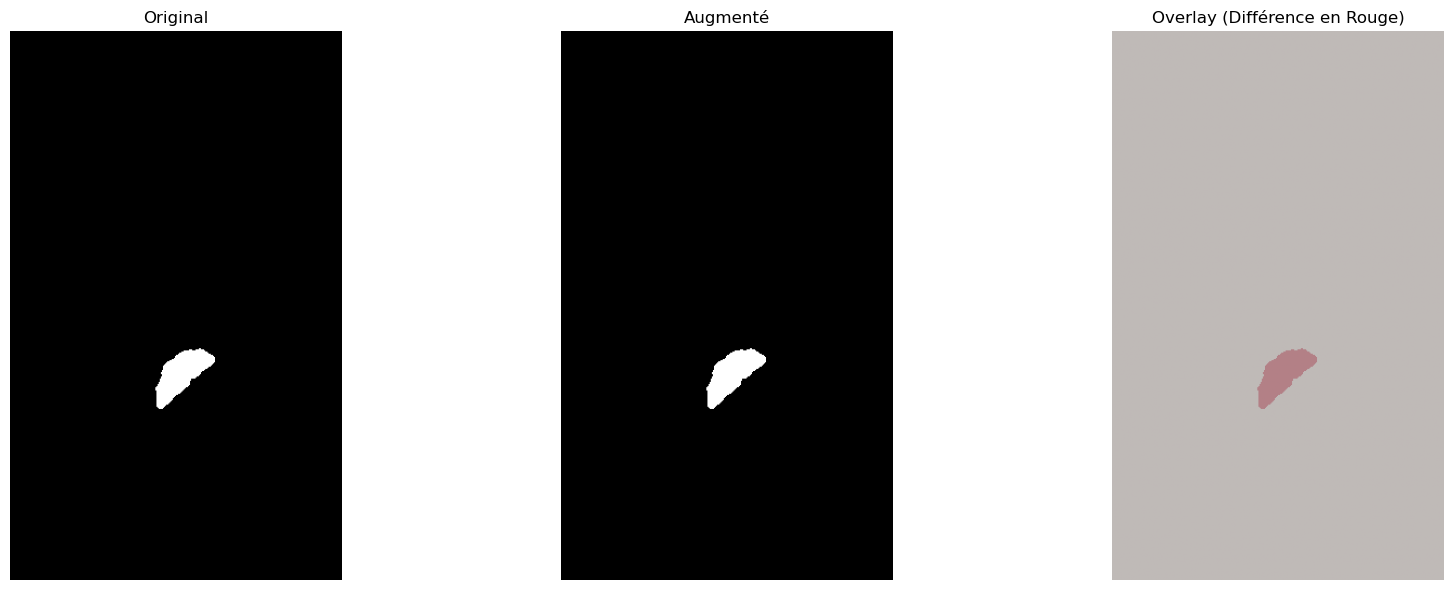

In [21]:
augmented_mask = "../data\processed_data\PanTS_00000052\segmentation\pancreas_tail.nii.gz"
origin_mask = "../data\PanTS\Labels Extracted\PanTS_00000052\segmentations\pancreas_tail.nii.gz"
augmented_mask = nib.load(augmented_mask).get_fdata()
orig_mask = nib.load(origin_mask).get_fdata()
visualize_original_vs_augmented(original_mask=orig_mask, augmented_mask=augmented_mask)